In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from google.colab import files

In [ ]:
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
if not os.path.exists('cifake_data'):
    !kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
    !unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d cifake_data

In [ ]:
IMG_SIZE = (96, 96)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake_data/train',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'cifake_data/train',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# TAKE SMALL SUBSETS (biggest speed gain)
train_ds = train_ds.take(500)   # instead of full dataset
val_ds = val_ds.take(200)

Found 100000 files belonging to 2 classes.
Using 80000 files for training.
Found 100000 files belonging to 2 classes.
Using 20000 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.fit(train_ds, epochs=10
          )

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 223s 429ms/step - accuracy: 0.8062 - loss: 0.4102
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 245s 395ms/step - accuracy: 0.8597 - loss: 0.3202
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 395ms/step - accuracy: 0.8662 - loss: 0.3114
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 397ms/step - accuracy: 0.8677 - loss: 0.3063
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 398ms/step - accuracy: 0.8712 - loss: 0.3047
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 390ms/step - accuracy: 0.8713 - loss: 0.3021
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 401ms/step - accuracy: 0.8727 - loss: 0.2997
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 404ms/step - accuracy: 0.8693 - loss: 0.3038
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 207s 413ms/step - accuracy: 0.8728 - loss: 0.3014
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 207s 414ms/step - accuracy: 0.8725 - loss: 0.3012


In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

200/200 ━━━━━━━━━━━━━━━━━━━━ 86s 414ms/step - accuracy: 0.8825 - loss: 0.2765
Validation Accuracy: 88.25%


Confusion Matrix:
 [[5645  777]
 [ 727 5651]]


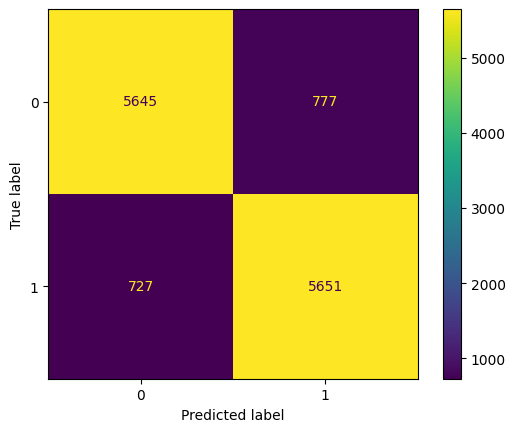

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    preds = (preds > 0.5).astype(int).flatten()
    labels = labels.numpy().astype(int).flatten()

    y_true.extend(labels)
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()